# Dataset report — figures

Recomputes every dataset number quoted in `README.md` straight from the annotation
`.txt` files, through the same code path (`domain.annotations`, `domain.dataset`) that
`create_dataset.py` uses, and renders the figures into `research/figures/`.

Run top to bottom. The manifest section (§6 onward) reads audio headers for every
recording, so it takes ~1 min the first time; everything before it is instant.

## 1. Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath

from core.config import P, settings
from core.setup import setup_project_path

setup_project_path(PROJECT_DIR)
FIGURE_DIR = PROJECT_DIR / "research" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [ ]:
# --- Chart style -------------------------------------------------------------
# Palette validated with the dataviz palette checker (light surface #fcfcfb):
# categorical slots 1-3 clear the all-pairs CVD and normal-vision floors.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # categorical slots 1-3
CRITICAL = "#d03b3b"  # status: data lost
BLUE = "#2a78d6"
BLUE_FADED = "#b7d3f6"  # sequential blue, step 150

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 9,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 24,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
    }
)


def subtitle(ax, text):
    """One line of secondary ink under the title — the chart's 'so what'."""
    ax.annotate(
        text,
        xy=(0, 1),
        xytext=(0, 8),
        xycoords="axes fraction",
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=8.5,
        color=INK_2,
    )


def style_value_axis(ax, axis="x"):
    """Recessive hairline grid on the value axis only; no baseline spine on it."""
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if axis == "x":
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_color(BASELINE)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color(BASELINE)


_K = 0.5523  # circular-arc control-point constant for a cubic Bezier


def _square_path(x0, y0, w, h):
    return MplPath(
        [(x0, y0), (x0 + w, y0), (x0 + w, y0 + h), (x0, y0 + h), (x0, y0)],
        [MplPath.MOVETO] + [MplPath.LINETO] * 3 + [MplPath.CLOSEPOLY],
    )


def _rounded_path(x0, y0, w, h, rx, ry, side="right"):
    """Rectangle with the two corners on `side` rounded — the mark spec's data-end.

    `rx` and `ry` are separate because the axes are in different units: one shared
    radius would stretch the arc into a spike on whichever axis has the wider range.
    """
    rx, ry = min(abs(rx), abs(w)), min(abs(ry), abs(h) / 2)
    if rx <= 0 or ry <= 0 or w == 0 or h == 0:
        return _square_path(x0, y0, w, h)
    x1, y1 = x0 + w, y0 + h

    if side == "right":
        verts = [
            (x0, y0),
            (x1 - rx, y0),
            (x1 - rx + rx * _K, y0),
            (x1, y0 + ry - ry * _K),
            (x1, y0 + ry),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0, y1),
            (x0, y0),
        ]
    else:  # "top"
        verts = [
            (x0, y0),
            (x1, y0),
            (x1, y1 - ry),
            (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1),
            (x1 - rx, y1),
            (x0 + rx, y1),
            (x0 + rx - rx * _K, y1),
            (x0, y1 - ry + ry * _K),
            (x0, y1 - ry),
            (x0, y0),
        ]
    codes = [
        MplPath.MOVETO,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CLOSEPOLY,
    ]
    return MplPath(verts, codes)


def _x_per_y(ax):
    """Data-x units that render the same on-screen length as one data-y unit.

    The rounding radius is a *visual* 4px-ish arc, so it has to be converted through
    the axes aspect — otherwise a bar spanning 3,000 x-units gets a radius of 0.2 and
    renders square.
    """
    box = ax.get_position()
    width_in = ax.figure.get_figwidth() * box.width
    height_in = ax.figure.get_figheight() * box.height
    x_range = abs(np.diff(ax.get_xlim())[0])
    y_range = abs(np.diff(ax.get_ylim())[0])
    return (x_range / width_in) / (y_range / height_in)


def barh(ax, ys, widths, color, height=0.62, left=None, radius_frac=0.30, **kw):
    """Horizontal bars with a rounded data-end. `left` enables stacking."""
    ys = np.atleast_1d(np.asarray(ys, dtype=float))
    widths = np.asarray(widths, dtype=float)
    left = np.zeros_like(widths) if left is None else np.asarray(left, dtype=float)
    ry = height * radius_frac
    rx = ry * _x_per_y(ax)
    for y, w, x0 in zip(ys, widths, left):
        ax.add_patch(
            PathPatch(
                _rounded_path(x0, y - height / 2, w, height, rx, ry, "right"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


def barv(ax, xs, heights, color, width=0.68, radius_frac=0.30, **kw):
    """Vertical bars with a rounded top."""
    xs = np.atleast_1d(np.asarray(xs, dtype=float))
    heights = np.asarray(heights, dtype=float)
    rx = width * radius_frac
    ry = rx / _x_per_y(ax)
    for x, h in zip(xs, heights):
        ax.add_patch(
            PathPatch(
                _rounded_path(x - width / 2, 0, width, h, rx, ry, "top"),
                facecolor=color,
                edgecolor="none",
                **kw,
            )
        )
    return ax


def save(fig, name):
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"saved -> {path.relative_to(PROJECT_DIR)}")

## 2. Load the annotations

`load_annotations` walks the species folders, keeps a `.txt` only when the matching
`.wav` exists, normalizes call codes through the synonym map, clips high frequency to
Nyquist and drops degenerate boxes.

In [ ]:
import logging

logging.getLogger("domain.annotations").setLevel(logging.ERROR)

from domain.annotations import load_annotations
from domain.species import VALID_PAIRS, Species

# `create_dataset.py` reads `data/cleaned`; fall back to `data/raw` when it is absent.
SOURCE_DIR = next(d for d in (settings.data_dir / "cleaned", settings.raw_dir) if d.exists())
print("source:", SOURCE_DIR.relative_to(PROJECT_DIR))

annotations = load_annotations(SOURCE_DIR)
annotations["pair"] = annotations.species + "/" + annotations.call_type

SPECIES_NAME = {s.name.lower(): s.value.replace("_", " ") for s in Species}

print(
    f"{len(annotations):,} annotations | {annotations.species.nunique()} species | "
    f"{annotations.pair.nunique()} distinct (species, call type) pairs"
)
print(
    f"{annotations[~annotations.requires_review].pair.nunique()} pairs are in the declared vocabulary; "
    f"{annotations.requires_review.mean():.1%} of records flagged requires_review"
)
print(f"{annotations.audio_path.nunique():,} recordings")
annotations.head()

source: data/raw


19,029 annotations | 8 species | 65 distinct (species, call type) pairs
41 pairs are in the declared vocabulary; 1.8% of records flagged requires_review
2,790 recordings


,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,inband_power_db_fs,species,call_type,audio_path,requires_review,duration_s,bandwidth_hz,rating,pair
0,0.532,0.874,"6,590.400","10,840.200",-32.330,sb,ppc,/home/nhrot/Prog/tesis-primate/data/raw/bolivi...,False,0.343,"4,249.800",NaN,sb/ppc
1,0.884,1.121,"6,698.700","11,071.500",-30.190,sb,ppc,/home/nhrot/Prog/tesis-primate/data/raw/bolivi...,False,0.237,"4,372.800",NaN,sb/ppc
2,1.466,1.764,"8,466.500","13,211.400",-37.030,sb,ppc,/home/nhrot/Prog/tesis-primate/data/raw/bolivi...,False,0.297,"4,744.900",NaN,sb/ppc
3,2.143,2.299,"9,790.140","12,509.623",-35.460,sb,ppc,/home/nhrot/Prog/tesis-primate/data/raw/bolivi...,False,0.156,"2,719.483",NaN,sb/ppc
4,4.410,5.019,"7,350.000","9,117.700",-40.300,sb,lpc,/home/nhrot/Prog/tesis-primate/data/raw/bolivi...,False,0.610,"1,767.700",NaN,sb/lpc


In [ ]:
# --- The experiment subset, exactly as `create_dataset.py` selects it ---------
MIN_PAIR_COUNT = 500
EXCLUDED_PAIRS = {("lw", "cc"), ("sm", "fc")}  # nesting phrases

keep = ~annotations[["species", "call_type"]].apply(tuple, axis=1).isin(EXCLUDED_PAIRS)
candidates = annotations[keep].copy()
candidates["low_freq_hz"] = candidates.low_freq_hz.clip(lower=P.f_min)

pair_counts = candidates.pair.value_counts()
CLASSES = sorted(pair_counts[pair_counts >= MIN_PAIR_COUNT].index)
experiment = candidates[candidates.pair.isin(CLASSES)].copy()

print(f"{len(CLASSES)} classes, {len(experiment):,} annotations")
print(", ".join(CLASSES))

10 classes, 14,125 annotations
aa/gc, ac/bc, as/bc, as/hc, lw/cs, pt/dc, sb/ppc, sb/spc, sm/cc, sm/fs


## 3. Scale range

The property that drives the architecture: three orders of magnitude of duration on a
single axis, against the 10–100× that COCO-scale detectors are built for.

In [ ]:
scale = pd.DataFrame(
    {
        "minimum": [annotations.duration_s.min(), annotations.bandwidth_hz.min()],
        "maximum": [annotations.duration_s.max(), annotations.bandwidth_hz.max()],
    },
    index=["duration (s)", "bandwidth (Hz)"],
)
scale["ratio"] = scale.maximum / scale.minimum
scale

,minimum,maximum,ratio
duration (s),0.034,73.324,"2,134.137"
bandwidth (Hz),224.019,"21,783.880",97.241


## 4. Figure — annotations per (species, call type)

The core "how much data per combination" figure. Bars are ordered by count; the ten
classes that clear the 500-annotation threshold are drawn in full blue, everything else
recedes. `lw/cc` is called out because it clears the threshold but is dropped anyway —
it is the phrase that contains `lw/cs`.

saved -> research/figures/annotations_per_pair.png


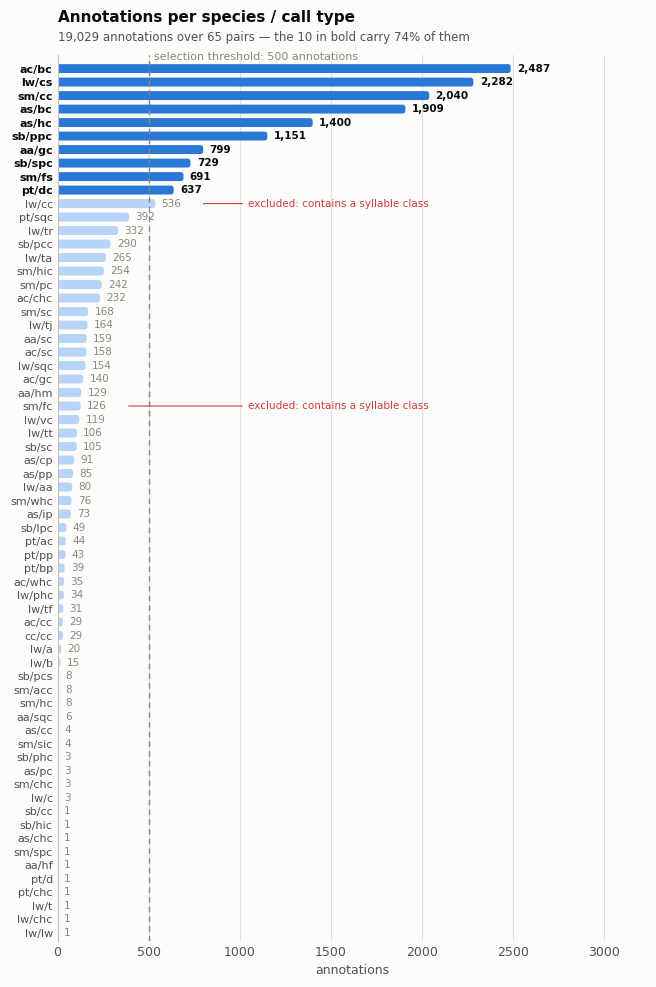

In [ ]:
counts = annotations.pair.value_counts()
selected = set(CLASSES)

fig, ax = plt.subplots(figsize=(7.6, 11.5))
ys = np.arange(len(counts))
ax.set_xlim(0, counts.max() * 1.30)
ax.set_ylim(len(counts) - 0.4, -1.0)

for y, (pair, n) in zip(ys, counts.items()):
    is_selected = pair in selected
    barh(ax, [y], [n], BLUE if is_selected else BLUE_FADED, height=0.66)
    ax.text(
        n + counts.max() * 0.014,
        y,
        f"{n:,}",
        va="center",
        ha="left",
        fontsize=7.5,
        color=INK if is_selected else MUTED,
        fontweight="bold" if is_selected else "normal",
    )

ax.axvline(MIN_PAIR_COUNT, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(
    MIN_PAIR_COUNT + counts.max() * 0.012,
    -0.85,
    f"selection threshold: {MIN_PAIR_COUNT} annotations",
    color=MUTED,
    fontsize=8,
    va="center",
    ha="left",
)

ax.set_yticks(ys)
ax.set_yticklabels(counts.index, fontsize=8)
for label, pair in zip(ax.get_yticklabels(), counts.index):
    if pair in selected:
        label.set_color(INK)
        label.set_fontweight("bold")

for pair in ("lw/cc", "sm/fc"):
    y = list(counts.index).index(pair)
    ax.annotate(
        "excluded: contains a syllable class",
        xy=(counts[pair] + counts.max() * 0.10, y),
        xytext=(counts.max() * 0.42, y),
        fontsize=7.5,
        color=CRITICAL,
        va="center",
        arrowprops=dict(arrowstyle="-", color=CRITICAL, linewidth=0.8),
    )

style_value_axis(ax, "x")
ax.set_xlabel("annotations")
ax.set_title("Annotations per species / call type")
subtitle(
    ax,
    f"{len(annotations):,} annotations over {annotations.pair.nunique()} pairs — the "
    f"{len(CLASSES)} in bold carry {len(experiment) / len(annotations):.0%} of them",
)
save(fig, "annotations_per_pair")
plt.show()

## 5. Figure — duration and frequency band per class

Left: duration on a log axis, with the 3 s clip length and the 6 s hard limit marked
(see §7). Right: the frequency band each class occupies, 5th to 95th percentile — this
is the "species separate by frequency, call types within a species do not" claim.

saved -> research/figures/class_geometry.png


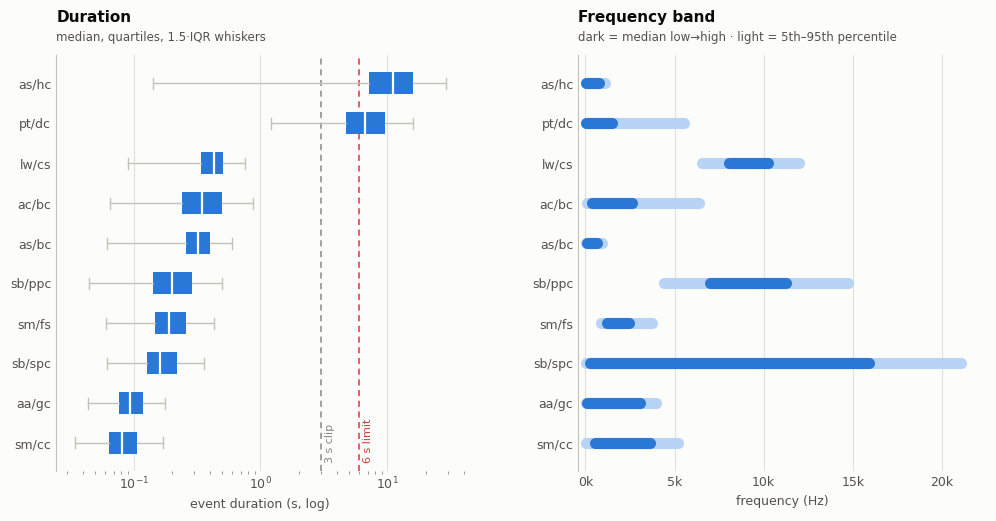

In [ ]:
# Longest class on top, so both panels read in the same order.
order = experiment.groupby("pair").duration_s.median().sort_values(ascending=False).index.tolist()
positions = np.arange(1, len(order) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), gridspec_kw={"wspace": 0.28})

# --- left: duration ---------------------------------------------------------
ax = axes[0]
data = [experiment.loc[experiment.pair == p, "duration_s"].values for p in order]
parts = ax.boxplot(
    data,
    orientation="horizontal",
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=SURFACE, linewidth=1.6),
    whiskerprops=dict(color=BASELINE, linewidth=1),
    capprops=dict(color=BASELINE, linewidth=1),
)
for box in parts["boxes"]:
    box.set(facecolor=BLUE, edgecolor="none")

ax.set_xscale("log")
ax.set_ylim(len(order) + 0.7, 0.3)
for x, color, text in [
    (P.clip_len_s, MUTED, "3 s clip"),
    (2 * P.clip_len_s, CRITICAL, "6 s limit"),
]:
    ax.axvline(x, color=color, linewidth=1.1, linestyle=(0, (4, 3)), zorder=1)
    ax.text(
        x * 1.07,
        len(order) + 0.5,
        text,
        color=color,
        fontsize=8,
        va="bottom",
        ha="left",
        rotation=90,
    )

ax.set_yticks(positions, order)
style_value_axis(ax, "x")
ax.set_xlabel("event duration (s, log)")
ax.set_title("Duration")
subtitle(ax, "median, quartiles, 1.5·IQR whiskers")

# --- right: frequency band --------------------------------------------------
ax = axes[1]
band = (
    experiment.groupby("pair")
    .agg(
        lo=("low_freq_hz", lambda s: s.quantile(0.05)),
        hi=("high_freq_hz", lambda s: s.quantile(0.95)),
        lo_med=("low_freq_hz", "median"),
        hi_med=("high_freq_hz", "median"),
    )
    .loc[order]
)

for y, (_, row) in zip(positions, band.iterrows()):
    ax.plot(
        [row.lo, row.hi], [y, y], color=BLUE_FADED, linewidth=8, solid_capstyle="round", zorder=2
    )
    ax.plot(
        [row.lo_med, row.hi_med], [y, y], color=BLUE, linewidth=8, solid_capstyle="round", zorder=3
    )

ax.set_yticks(positions, order)
ax.set_ylim(len(order) + 0.7, 0.3)
ax.set_xlim(-400, P.f_max * 1.02)
ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
style_value_axis(ax, "x")
ax.set_xlabel("frequency (Hz)")
ax.set_title("Frequency band")
subtitle(ax, "dark = median low→high · light = 5th–95th percentile")
save(fig, "class_geometry")
plt.show()

## 6. Figure — duration × bandwidth, one panel per class

Ten classes is past the point where colour can carry identity, so this is faceted: every
panel shows all classes in grey and one in blue.

`ac/bc` (bandwidth CV 0.60) and `sm/fs` (0.63) split into two clearly separated clouds,
and `sb/ppc` (0.47) is one diffuse smear — evidence that those labels group more than one
call variant, which is the clustering item in the README's next steps.

saved -> research/figures/class_geometry_facets.png


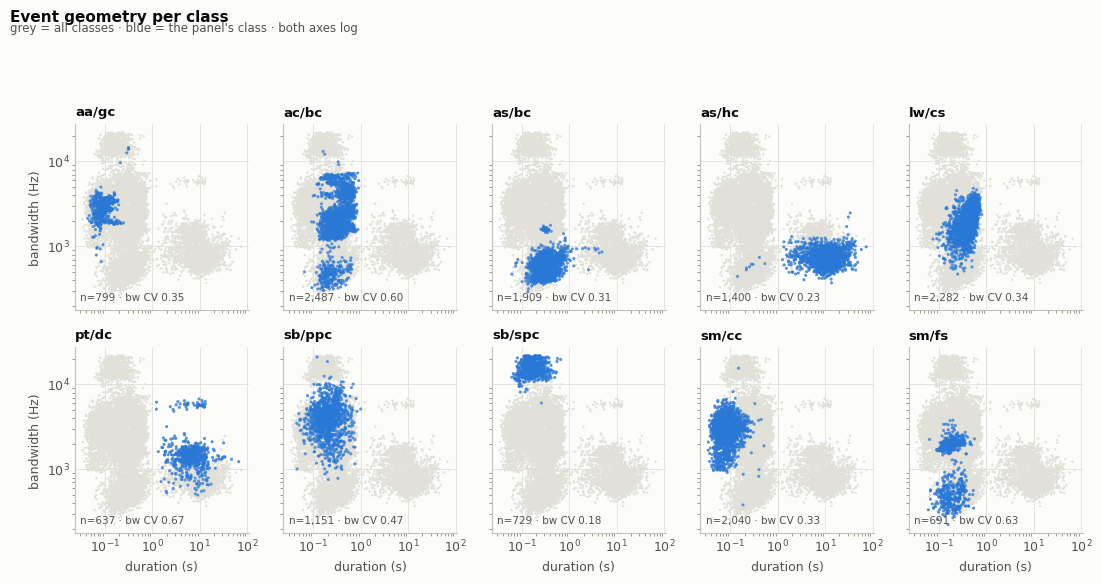

In [ ]:
cv = experiment.groupby("pair").bandwidth_hz.std() / experiment.groupby("pair").bandwidth_hz.mean()

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6), sharex=True, sharey=True)
for ax, pair in zip(axes.ravel(), CLASSES):
    ax.scatter(
        experiment.duration_s, experiment.bandwidth_hz, s=3, color=GRID, edgecolors="none", zorder=1
    )
    sub = experiment[experiment.pair == pair]
    ax.scatter(
        sub.duration_s, sub.bandwidth_hz, s=5, color=BLUE, edgecolors="none", alpha=0.75, zorder=2
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{pair}", fontsize=9.5, pad=6)
    ax.annotate(
        f"n={len(sub):,} · bw CV {cv[pair]:.2f}",
        xy=(0.03, 0.05),
        xycoords="axes fraction",
        fontsize=7.5,
        color=INK_2,
    )
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)

for ax in axes[-1]:
    ax.set_xlabel("duration (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("bandwidth (Hz)")
fig.subplots_adjust(top=0.84)
fig.suptitle(
    "Event geometry per class",
    x=0.075,
    y=1.045,
    ha="left",
    fontsize=11,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.075,
    1.005,
    "grey = all classes · blue = the panel's class · both axes log",
    ha="left",
    fontsize=8.5,
    color=INK_2,
)
save(fig, "class_geometry_facets")
plt.show()

## 7. Windowing — build the manifest

From here on the notebook runs the real windowing: 3 s clips at a 1.5 s hop, an event
kept only when at least `min_overlap = 0.5` of its duration falls inside the window,
then a 70/10/20 split **by recording**. Reads the header of every `.wav`, so it takes
about a minute.

In [ ]:
from domain.dataset import build_manifest, split_manifest
from domain.species import LabelSet

labels = LabelSet(CLASSES)
experiment["label"] = experiment.pair
manifest = build_manifest(experiment, labels)
splits = dict(zip(("train", "val", "test"), split_manifest(manifest, seed=42)))

summary = pd.DataFrame(
    {
        name: {
            "recordings": len({w.audio_path for w in split}),
            "windows": len(split),
            "boxes": int(sum(len(w.boxes) for w in split)),
        }
        for name, split in splits.items()
    }
).T
summary["share of recordings"] = summary.recordings / summary.recordings.sum()
summary

,recordings,windows,boxes,share of recordings
train,1166,8022,16674,0.699
val,166,1043,2183,0.100
test,335,2490,5343,0.201


In [ ]:
boxes_per_split = (
    pd.DataFrame(
        {
            name: pd.Series(
                [labels.name(int(c)) for w in split for c in w.boxes[:, 4]]
            ).value_counts()
            for name, split in splits.items()
        }
    )
    .fillna(0)
    .astype(int)
)
boxes_per_split["annotations"] = experiment.pair.value_counts()
boxes_per_split = boxes_per_split.sort_values("train", ascending=False)
boxes_per_split

,train,val,test,annotations
lw/cs,3273,450,692,2282
ac/bc,3001,280,1463,2487
sm/cc,2893,376,635,2040
as/bc,2166,489,1020,1909
sb/ppc,1719,122,372,1151
sb/spc,1064,90,256,729
aa/gc,1007,110,398,799
sm/fs,893,156,277,691
pt/dc,338,68,116,637
as/hc,320,42,114,1400


## 8. Figure — boxes per class and split

A single annotation can land in two windows (3 s clip, 1.5 s hop), so box counts run
above annotation counts — except for `as/hc` and `pt/dc`, where they collapse. That is
the defect the next figure isolates.

saved -> research/figures/boxes_per_split.png


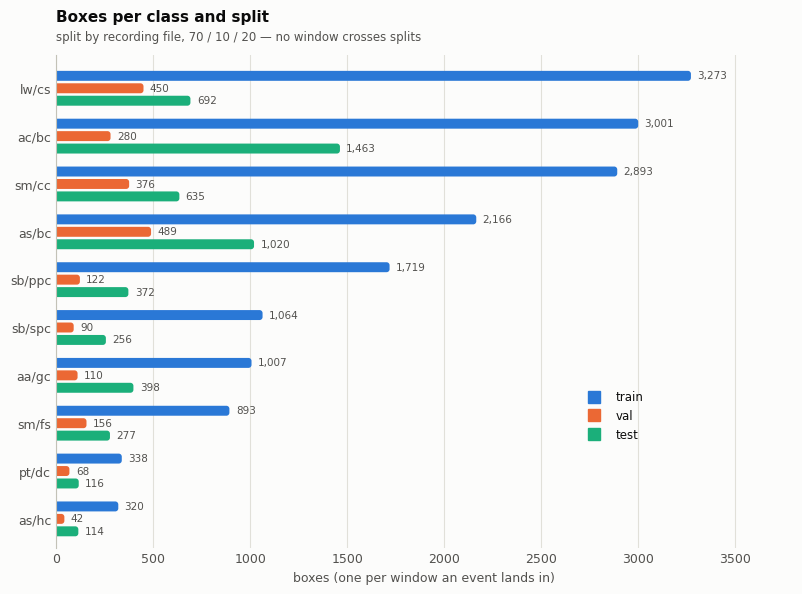

In [ ]:
split_names = ["train", "val", "test"]
order = boxes_per_split.index.tolist()

fig, ax = plt.subplots(figsize=(9.5, 6.4))
peak = boxes_per_split[split_names].values.max()
ax.set_xlim(0, peak * 1.16)
ax.set_ylim(len(order) - 0.4, -0.7)
step = 0.26
for i, (name, color) in enumerate(zip(split_names, SERIES)):
    ys = np.arange(len(order)) + (i - 1) * step
    values = boxes_per_split.loc[order, name].values
    barh(ax, ys, values, color, height=step * 0.80)
    for y, v in zip(ys, values):
        ax.text(v + peak * 0.010, y, f"{v:,}", va="center", ha="left", fontsize=7.5, color=INK_2)

ax.set_yticks(np.arange(len(order)), order)
ax.set_ylim(len(order) - 0.4, -0.7)
style_value_axis(ax, "x")
ax.set_xlabel("boxes (one per window an event lands in)")
ax.set_title("Boxes per class and split")
subtitle(ax, "split by recording file, 70 / 10 / 20 — no window crosses splits")

handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=c, label=n)
    for c, n in zip(SERIES, split_names)
]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.70, 0.34), ncol=1)
save(fig, "boxes_per_split")
plt.show()

## 9. Figure — events the windowing cannot reach

An event is kept only if at least half its duration is inside a 3 s window, so nothing
longer than 6 s can ever be assigned to one. This is a silent loss: the annotations are
in the table, counted in every "annotations per class" figure, and never seen by the
model.

1,514 of 14,125 annotations (10.7%) exceed 6 s and can never enter a training window
1,907 (13.5%) exceed the 3 s clip and survive only clipped to the window edge
saved -> research/figures/unreachable_events.png


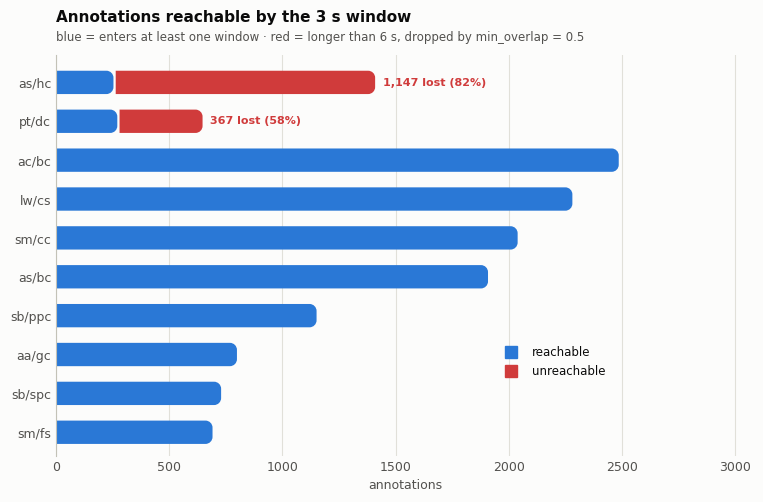

In [ ]:
LIMIT = 2 * P.clip_len_s
reach = experiment.assign(unreachable=experiment.duration_s > LIMIT)
per_class = reach.groupby("pair").unreachable.agg(["sum", "count"])
per_class.columns = ["unreachable", "total"]
per_class["reachable"] = per_class.total - per_class.unreachable
per_class["lost"] = per_class.unreachable / per_class.total
per_class = per_class.sort_values(["lost", "total"], ascending=False)

print(
    f"{per_class.unreachable.sum():,} of {len(experiment):,} annotations "
    f"({per_class.unreachable.sum() / len(experiment):.1%}) exceed {LIMIT:g} s "
    "and can never enter a training window"
)
print(
    f"{(experiment.duration_s > P.clip_len_s).sum():,} "
    f"({(experiment.duration_s > P.clip_len_s).mean():.1%}) exceed the 3 s clip and "
    "survive only clipped to the window edge"
)

fig, ax = plt.subplots(figsize=(9, 5.2))
ys = np.arange(len(per_class))
ax.set_xlim(0, per_class.total.max() * 1.24)
ax.set_ylim(len(per_class) - 0.4, -0.7)
# 2px surface gap between the two stacked segments, per the mark spec.
gap = per_class.total.max() * 0.004
barh(ax, ys, per_class.reachable.values, BLUE, height=0.6)
barh(
    ax,
    ys,
    per_class.unreachable.values,
    CRITICAL,
    height=0.6,
    left=per_class.reachable.values + gap,
)

for y, (_, row) in zip(ys, per_class.iterrows()):
    if row.unreachable:
        ax.text(
            row.total + per_class.total.max() * 0.018,
            y,
            f"{int(row.unreachable):,} lost ({row.lost:.0%})",
            va="center",
            ha="left",
            fontsize=8,
            color=CRITICAL,
            fontweight="bold",
        )

ax.set_yticks(ys, per_class.index)
ax.set_ylim(len(per_class) - 0.4, -0.7)
style_value_axis(ax, "x")
ax.set_xlabel("annotations")
ax.set_title("Annotations reachable by the 3 s window")
subtitle(
    ax, "blue = enters at least one window · red = longer than 6 s, dropped by min_overlap = 0.5"
)

handles = [
    plt.Line2D([], [], marker="s", linestyle="", markersize=8, color=c, label=n)
    for c, n in [(BLUE, "reachable"), (CRITICAL, "unreachable")]
]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.62, 0.30), ncol=1)
save(fig, "unreachable_events")
plt.show()

## 10. Figure — boxes per window

Sets the query budget: the decoder needs enough queries to cover the busiest clip, and
no more — surplus queries turn into prediction noise.

saved -> research/figures/boxes_per_window.png


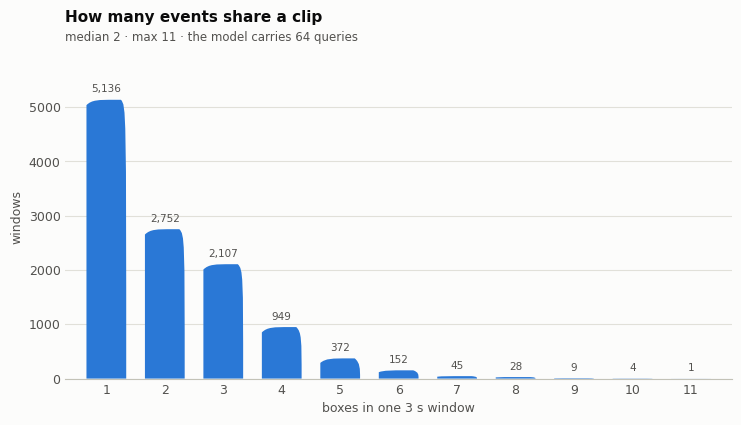

In [ ]:
per_window = np.array([len(w.boxes) for w in manifest])
n_queries = 64

fig, ax = plt.subplots(figsize=(8.6, 4.2))
values, edges = np.histogram(per_window, bins=np.arange(0.5, per_window.max() + 1.5))
centres = np.arange(1, per_window.max() + 1)
span = values.max()
ax.set_ylim(0, span * 1.16)
ax.set_xlim(0.3, per_window.max() + 0.7)
barv(ax, centres, values, BLUE)
for x, v in zip(centres, values):
    if v:
        ax.text(x, v + span * 0.02, f"{v:,}", ha="center", va="bottom", fontsize=7.5, color=INK_2)

ax.set_xticks(centres)
ax.grid(True, axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.set_xlabel("boxes in one 3 s window")
ax.set_ylabel("windows")
ax.set_title("How many events share a clip")
subtitle(
    ax,
    f"median {int(np.median(per_window))} · max {per_window.max()} · "
    f"the model carries {n_queries} queries",
)
save(fig, "boxes_per_window")
plt.show()

## 11. Figure — a window as the model sees it

The log-mel input tensor with its ground-truth boxes, in the same normalized
`cxcywh` + HTK-mel coordinates the criterion matches on.

saved -> research/figures/window_example.png


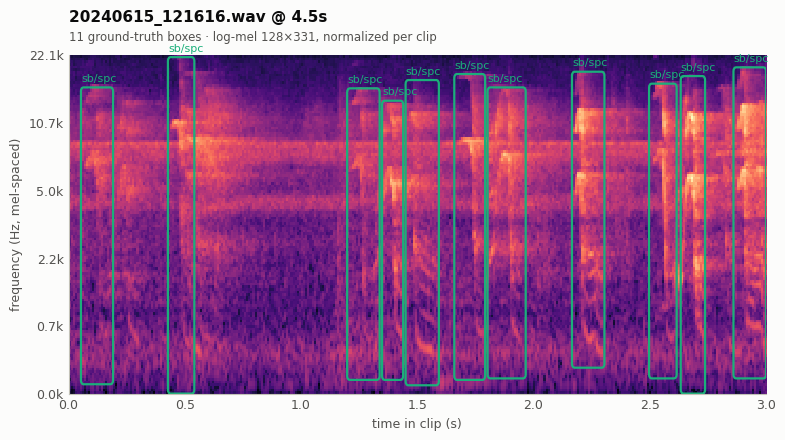

In [ ]:
from matplotlib.patches import FancyBboxPatch
from domain.dataset import CallBoxDataset
from utils.audio import y_to_hz


def plot_window(index, split="train"):
    window = splits[split][index]
    image, target = CallBoxDataset([window], P)[0]
    spectrogram = image[0].numpy()

    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.imshow(
        spectrogram,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, P.clip_len_s, 0, 1),
        interpolation="nearest",
    )

    for box, class_id in zip(target["boxes"].numpy(), target["labels"].tolist()):
        cx, cy, w, h = box
        ax.add_patch(
            FancyBboxPatch(
                ((cx - w / 2) * P.clip_len_s, cy - h / 2),
                w * P.clip_len_s,
                h,
                boxstyle="round,pad=0,rounding_size=0.012",
                linewidth=1.6,
                edgecolor=SERIES[2],
                facecolor="none",
            )
        )
        ax.text(
            (cx - w / 2) * P.clip_len_s,
            cy + h / 2 + 0.012,
            labels.name(class_id),
            color=SERIES[2],
            fontsize=8,
            va="bottom",
        )

    ticks = np.linspace(0, 1, 6)
    ax.set_yticks(ticks, [f"{y_to_hz(np.array([t]), P)[0] / 1000:.1f}k" for t in ticks])
    ax.set_xlabel("time in clip (s)")
    ax.set_ylabel("frequency (Hz, mel-spaced)")
    ax.set_title(f"{Path(window.audio_path).name} @ {window.clip_start_s:.1f}s")
    subtitle(
        ax,
        f"{len(target['boxes'])} ground-truth boxes · log-mel "
        f"{P.n_mels}×{P.n_frames}, normalized per clip",
    )
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)
    return fig


busiest = int(np.argmax([len(w.boxes) for w in splits["train"]]))
fig = plot_window(busiest)
save(fig, "window_example")
plt.show()

## 12. Every number the README quotes

Regenerate this cell after any change to the annotations or to `Parameters`, and paste
the output back into §4 of the README.

In [ ]:
print(f"annotations                 {len(annotations):,}")
print(f"species                     {annotations.species.nunique()}")
print(
    f"distinct pairs              {annotations.pair.nunique()} "
    f"({annotations[~annotations.requires_review].pair.nunique()} in the vocabulary)"
)
print(f"requires_review             {annotations.requires_review.mean():.1%}")
print(
    f"duration  min / max         {annotations.duration_s.min():.3f} s / "
    f"{annotations.duration_s.max():.1f} s  ({annotations.duration_s.max() / annotations.duration_s.min():,.0f}x)"
)
print(
    f"bandwidth min / max         {annotations.bandwidth_hz.min():,.0f} Hz / "
    f"{annotations.bandwidth_hz.max():,.0f} Hz  ({annotations.bandwidth_hz.max() / annotations.bandwidth_hz.min():.0f}x)"
)
print(f"experiment classes          {len(CLASSES)}")
print(f"experiment annotations      {len(experiment):,}")
print(f"windows train/val/test      {' / '.join(f'{len(s):,}' for s in splits.values())}")
print(
    f"recordings train/val/test   {' / '.join(f'{len({w.audio_path for w in s}):,}' for s in splits.values())}"
)
print(f"boxes/window  median / max  {int(np.median(per_window))} / {per_window.max()}")
print(
    f"unreachable (> 6 s)         {per_class.unreachable.sum():,} "
    f"({per_class.unreachable.sum() / len(experiment):.1%})"
)
print(
    f"sb/spc mean high freq       {experiment.loc[experiment.pair == 'sb/spc', 'high_freq_hz'].mean():,.0f} Hz"
)
print(
    f"sm/cc median duration       {experiment.loc[experiment.pair == 'sm/cc', 'duration_s'].median() * 1000:.0f} ms"
)
print(
    f"lw/cs minimum low freq      {experiment.loc[experiment.pair == 'lw/cs', 'low_freq_hz'].min():,.0f} Hz"
)

for container, content in [("lw/cc", "lw/cs"), ("sm/fc", "sm/fs")]:
    outer = annotations[annotations.pair == container]
    inner = annotations[annotations.pair == content]
    hits = total = 0
    for path, group in outer.groupby("audio_path"):
        nested = inner[inner.audio_path == path]
        for row in group.itertuples():
            total += 1
            hits += bool(
                (
                    (nested.begin_time_s >= row.begin_time_s - 1e-3)
                    & (nested.end_time_s <= row.end_time_s + 1e-3)
                ).any()
            )
    print(f"{container} containing a {content}   {hits}/{total} = {hits / max(total, 1):.1%}")

annotations                 19,029
species                     8
distinct pairs              65 (41 in the vocabulary)
requires_review             1.8%
duration  min / max         0.034 s / 73.3 s  (2,134x)
bandwidth min / max         224 Hz / 21,784 Hz  (97x)
experiment classes          10
experiment annotations      14,125
windows train/val/test      8,022 / 1,043 / 2,490
recordings train/val/test   1,166 / 166 / 335
boxes/window  median / max  2 / 11
unreachable (> 6 s)         1,514 (10.7%)
sb/spc mean high freq       16,110 Hz
sm/cc median duration       81 ms
lw/cs minimum low freq      3,687 Hz


lw/cc containing a lw/cs   505/536 = 94.2%
sm/fc containing a sm/fs   122/126 = 96.8%
